In [29]:
#Import libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#Machine Learning
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [30]:
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM

In [31]:
#Plot Style
plt.style.use("ggplot")
sns.set_palette("husl")

In [32]:
COL_NAMES = [
'duration','protocol_type','service','flag','src_bytes','dst_bytes','land',
'wrong_fragment','urgent','hot','num_failed_logins','logged_in',
'num_compromised','root_shell','su_attempted','num_root',
'num_file_creations','num_shells','num_access_files',
'num_outbound_cmds','is_host_login','is_guest_login','count',
'srv_count','serror_rate','srv_serror_rate','rerror_rate',
'srv_rerror_rate','same_srv_rate','diff_srv_rate',
'srv_diff_host_rate','dst_host_count','dst_host_srv_count',
'dst_host_same_srv_rate','dst_host_diff_srv_rate',
'dst_host_same_src_port_rate','dst_host_srv_diff_host_rate',
'dst_host_serror_rate','dst_host_srv_serror_rate',
'dst_host_rerror_rate','dst_host_srv_rerror_rate',
'label','difficulty_level'
]

In [33]:
#Load Dataset
train_path="./data/KCDTrain.txt"
test_path="./data/KCDTest.txt"
df_train=pd.read_csv(train_path, header=None, names=COL_NAMES)
df_test=pd.read_csv(test_path, header=None, names=COL_NAMES)
print("Training Data Shape:", df_train.shape)
print("Testing Data Shape:", df_test.shape)
df_raw = df_train.copy()
print("Raw Data Shape:", df_raw.shape)

Training Data Shape: (125973, 43)
Testing Data Shape: (22544, 43)
Raw Data Shape: (125973, 43)


In [34]:
#Mapping for Target Variable
attack_mapping= {
    'normal': 'normal',
    #DoS Attacks
    'back': 'DoS',
    'land': 'DoS',
    'neptune': 'DoS',
    'pod': 'DoS',
    'smurf': 'DoS',
    'teardrop': 'DoS',

    #Probe Attacks
    'satan': 'Probe',
    'ipsweep': 'Probe',
    'nmap': 'Probe',
    'portsweep': 'Probe',

    #R2L Attacks
    'guess_passwd': 'R2L',
    'ftp_write': 'R2L',
    'imap': 'R2L',
    'warezmaster': 'R2L',
    'warezclient': 'R2L',

    #U2R Attacks
    'buffer_overflow': 'U2R',
    'loadmodule': 'U2R',
    'perl': 'U2R',
    'rootkit': 'U2R'
}

In [35]:
#Create new column with attack categories
df_raw['attack_class'] = df_raw['label'].map(
    lambda x: attack_mapping.get(x, 'other')
)

In [36]:
#Encode Target Variable
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
y_master=le.fit_transform(df_raw['attack_class'])

In [37]:
#Extracting Features
#here
#Removing target-related columns
X_raw = df_raw.drop(columns=['label', 'attack_class'])

In [38]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
#Example dataset
X_resampled = df_train.drop("label", axis=1)  #drop the target column
y_resampled = df_train["label"]  
print("Features and target created")

Features and target created


In [39]:
#Encoding the target labels
labelencoder=LabelEncoder()
data=labelencoder.fit_transform(y_resampled)
print("Encoded target labels successfully")

Encoded target labels successfully


In [40]:
categorical_cols = ['protocol_type', 'service', 'flag']
print("Categorical columns:", categorical_cols)

Categorical columns: ['protocol_type', 'service', 'flag']


In [41]:
X_resampled_encoded=pd.get_dummies(X_resampled, columns=categorical_cols)
print("Shape before encoding:", X_resampled.shape)
print("Shape after encoding:", X_resampled_encoded.shape)
y_encoded = labelencoder.fit_transform(y_resampled)

Shape before encoding: (125973, 42)
Shape after encoding: (125973, 123)


In [42]:
from sklearn.ensemble import RandomForestClassifier
#Train Random Forest on encoded data
rf_model=RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_resampled_encoded, data) #data is your encoded target
rf_model.fit(X_resampled_encoded, y_encoded)
print("Random Forest model trained successfully on encoded data.")

Random Forest model trained successfully on encoded data.


In [43]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

#Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled_encoded, data, test_size=0.2, random_state=42
)

#Training model again
rf_model=RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

#Predict
y_pred=rf_model.predict(X_test)

# Metrics
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall   :", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score :", f1_score(y_test, y_pred, average='weighted'))

Accuracy : 0.9985314546537011
Precision: 0.9984941249767993
Recall   : 0.9985314546537011
F1 Score : 0.9984280000567617


In [44]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import f1_score
from sklearn.ensemble import RandomForestClassifier

#for Reduce memory
X_train=X_train.astype('float32')
X_test=X_test.astype('float32')

#here reseting indices
X_train=X_train.reset_index(drop=True)
y_train=pd.Series(y_train).reset_index(drop=True)

#Now sample
X_small=X_train.sample(n=20000, random_state=42)
y_small=y_train.loc[X_small.index]

#Random Forest
rf_model=RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred=rf_model.predict(X_test)

#Logistic Regression
lr_model=LogisticRegression(max_iter=500, solver='saga', n_jobs=-1)
lr_model.fit(X_small, y_small)
y_pred_lr=lr_model.predict(X_test)

#SVM
svm_model=LinearSVC()
svm_model.fit(X_small, y_small)
y_pred_svm=svm_model.predict(X_test)

#Comparison
print("\n--- Model Comparison (F1 Score) ---")
print("Random Forest F1:",
      f1_score(y_test, y_pred, average='weighted'))
print("Logistic Regression F1:",
      f1_score(y_test, y_pred_lr, average='weighted'))
print("SVM F1:",
      f1_score(y_test, y_pred_svm, average='weighted'))


--- Model Comparison (F1 Score) ---
Random Forest F1: 0.9984280000567617
Logistic Regression F1: 0.7574471554930385
SVM F1: 0.8353469289083802


In [45]:
#compute feature importance
feature_importance=pd.Series(rf_model.feature_importances_, index=X_resampled_encoded.columns)
importance_sorted=feature_importance.sort_values(ascending=False)
top_features=importance_sorted.head(25)

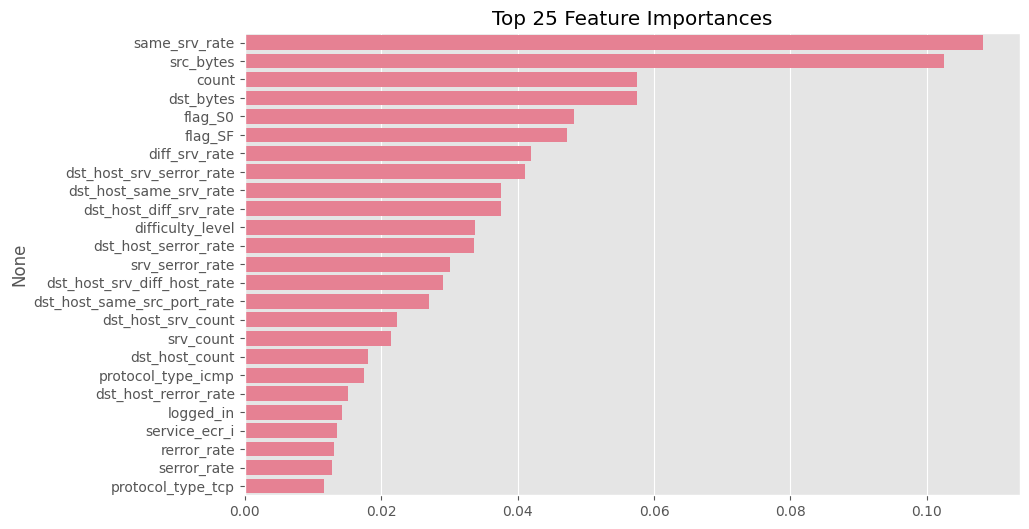

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,6))
sns.barplot(x=top_features.values, y=top_features.index)
plt.title("Top 25 Feature Importances")
plt.show()

In [47]:
#Identify low importance features
threshold=0.001  
low_importance_features=importance_sorted[importance_sorted < threshold].index.tolist()
print("Low importance features (importance < 0.001):")
for feature in low_importance_features:
    print(feature)

Low importance features (importance < 0.001):
is_guest_login
flag_SH
service_ftp
service_telnet
flag_RSTO
service_finger
service_smtp
service_urp_i
num_failed_logins
num_root
flag_S1
flag_RSTOS0
service_IRC
flag_OTH
num_file_creations
root_shell
land
service_bgp
service_imap4
service_uucp_path
service_auth
num_access_files
num_shells
service_time
service_X11
flag_S2
service_gopher
service_pm_dump
service_ssh
service_login
service_tftp_u
service_link
service_domain
service_ntp_u
su_attempted
service_discard
flag_S3
service_nntp
service_sunrpc
urgent
service_systat
service_Z39_50
service_ctf
service_tim_i
service_urh_i
service_daytime
service_uucp
service_mtp
service_whois
service_pop_2
service_netstat
service_pop_3
service_supdup
service_netbios_ns
service_name
service_echo
service_remote_job
service_ldap
service_sql_net
service_hostnames
service_rje
service_shell
service_csnet_ns
service_netbios_ssn
service_printer
service_http_443
service_kshell
service_nnsp
service_vmnet
service_red_

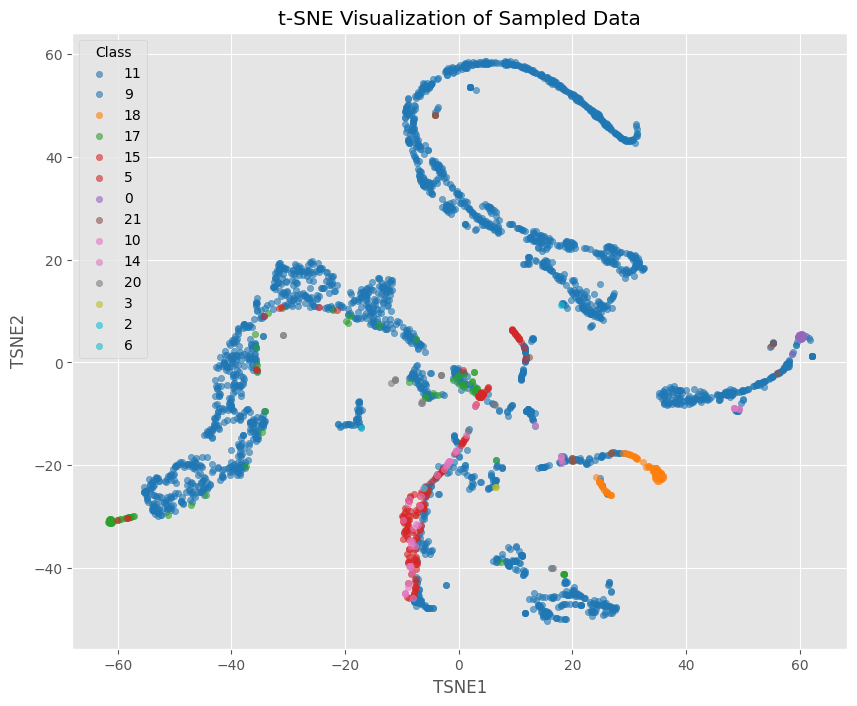

In [48]:
from sklearn.manifold import TSNE
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#Sample subset
sample_size=3000
rows=np.random.choice(X_resampled_encoded.shape[0], sample_size, replace=False)
X_sample=X_resampled_encoded.iloc[rows]
y_sample=y_encoded[rows]

#here fit t-SNE 
tsne=TSNE(n_components=2, perplexity=40, random_state=42) 
X_tsne=tsne.fit_transform(X_sample)  

#Converting to DataFrame 
tsne_df=pd.DataFrame({'TSNE1': X_tsne[:,0], 'TSNE2': X_tsne[:,1], 'class': y_sample})

#Plot
plt.figure(figsize=(10,8))
unique_classes=tsne_df['class'].unique()
colors=plt.cm.get_cmap('tab10', len(unique_classes))
for i, cls in enumerate(unique_classes):
    subset = tsne_df[tsne_df['class']==cls]
    plt.scatter(subset['TSNE1'], subset['TSNE2'], color=colors(i), label=str(cls), alpha=0.6, s=20)

plt.legend(title='Class')
plt.title("t-SNE Visualization of Sampled Data")
plt.xlabel("TSNE1")
plt.ylabel("TSNE2")
plt.show()

In [49]:
#Import libraries
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

In [50]:
#Creating a numeric pipeline
numeric_pipeline=Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),  #here Filling missing numeric values with median
    ('scaler', StandardScaler())                   #doing standardize features (mean=0, std=1)
])

In [51]:
#Select numeric columns
numeric_cols=X_resampled_encoded.select_dtypes(include=['int64', 'float64']).columns
X_numeric=X_resampled_encoded[numeric_cols]
#Fit and transform numeric features
X_numeric_processed = numeric_pipeline.fit_transform(X_numeric)
print("Numeric features processed shape:", X_numeric_processed.shape)

Numeric features processed shape: (125973, 39)


In [52]:
#Save the pipeline
import joblib
joblib.dump(numeric_pipeline, "numeric_pipeline.pkl")

['numeric_pipeline.pkl']

In [53]:
import joblib
#Load the Pipeline
prep=joblib.load("numeric_pipeline.pkl")

In [54]:
#Now selecting columns expected by pipeline
numeric_cols = prep.feature_names_in_
X_numeric = X_raw[numeric_cols]
#here
#Apply pipeline
X_signal = prep.transform(X_numeric)
print("\n--- Connection Architecture ---")
print("Pre-Selection Features :", X_raw.shape[1])
print("Post-Selection Signal  :", X_signal.shape[1])


--- Connection Architecture ---
Pre-Selection Features : 42
Post-Selection Signal  : 39


In [60]:
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
#Analyzing Normally Baselines
print("Analyzing Normally Baselines")

#Isolation Forest
iso = IsolationForest(contamination=0.03, random_state=42)
#Predict anomaly scores
iso.fit(X_signal)
df_raw['iso_label'] = iso.predict(X_signal)
df_raw['iso_score'] = iso.decision_function(X_signal)
df_raw['is_anomaly'] = (df_raw['iso_label'] == -1).astype(int)
#Convert predictions to binary anomaly labels
df_raw['is_anomaly'] = (df_raw['iso_label'] == -1).astype(int)

#Local Outlier Factor 
#LOF is computationally expensive, so we use a sample
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.03)
#Fit and predict on subset
lof_labels = lof.fit_predict(X_signal[:5000])
#Store results
df_raw['lof_label'] = 0
df_raw.loc[:4999, 'lof_label'] = lof_labels

#One-Class SVM 
#Create model
oc_svm = OneClassSVM(nu=0.05)
#Train FIRST
oc_svm.fit(X_signal[:5000])
#Then predict
svm_labels = oc_svm.predict(X_signal[:5000])

# Store results
df_raw['svm_label'] = 0
df_raw.loc[:4999, 'svm_label'] = svm_labels
#Train on a subset to learn normal behavior
oc_svm.fit(X_signal[:5000])
#final anomalies
df_raw['final_anomaly'] = (
    (df_raw['iso_label'] == -1) |
    (df_raw['lof_label'] == -1) |
    (df_raw['svm_label'] == -1)
)
print("Total anomalies detected:", df_raw['final_anomaly'].sum())
#Interpretation
print("Unsupervised Insight:")
print("DoS attacks show strong anomaly patterns, while U2R attacks are more subtle and difficult to detect.")

Analyzing Normally Baselines
Total anomalies detected: 4060
Unsupervised Insight:
DoS attacks show strong anomaly patterns, while U2R attacks are more subtle and difficult to detect.


In [61]:
anomaly_summary = pd.crosstab(
    df_raw['attack_class'],
    df_raw['final_anomaly']
)

print("\n--- Detailed Anomaly Breakdown ---")
print(anomaly_summary)
anomaly_percent = anomaly_summary.div(anomaly_summary.sum(axis=1), axis=0) * 100
print("\n--- Anomaly Percentage (%) ---")
print(anomaly_percent)



--- Detailed Anomaly Breakdown ---
final_anomaly  False  True 
attack_class               
DoS            45748    179
Probe           8603   3053
R2L              905     77
U2R               41     11
normal         66605    738
other             11      2

--- Anomaly Percentage (%) ---
final_anomaly      False      True 
attack_class                       
DoS            99.610251   0.389749
Probe          73.807481  26.192519
R2L            92.158859   7.841141
U2R            78.846154  21.153846
normal         98.904118   1.095882
other          84.615385  15.384615


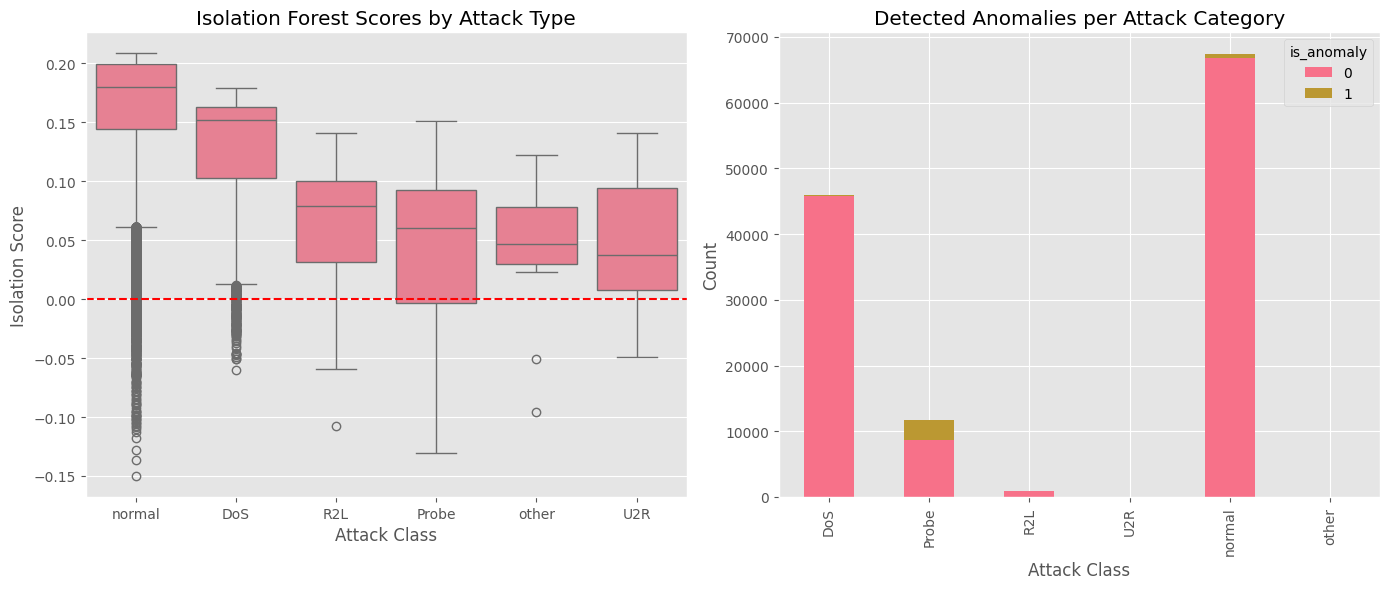

In [62]:
#Visualization of Anomaly Detection
plt.figure(figsize=(14,6))

#Box Plot
plt.subplot(1,2,1)

sns.boxplot(
    x='attack_class',
    y='iso_score',
    data=df_raw,
)
df_raw['is_anomaly'] = df_raw['iso_label'].map({1: 0, -1: 1})
df_raw['is_anomaly'] = df_raw['is_anomaly'].fillna(0).astype(int)
plt.axhline(0, color='red', linestyle='--')
plt.title("Isolation Forest Scores by Attack Type")
plt.xlabel("Attack Class")
plt.ylabel("Isolation Score")


#Stacked Bar Chart 
plt.subplot(1,2,2)
anomaly_counts = pd.crosstab(df_raw['attack_class'], df_raw['is_anomaly'])
anomaly_counts.plot(
    kind='bar',
    stacked=True,
    ax=plt.gca()
)
plt.title("Detected Anomalies per Attack Category")
plt.xlabel("Attack Class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [63]:
import pandas as pd
#Convert categorical features to numeric
X_signal=pd.get_dummies(X_raw)
print("Shape of X:",X_signal.shape)
print("Shape of y:",y_master.shape)

Shape of X: (125973, 123)
Shape of y: (125973,)


In [64]:
from sklearn.model_selection import train_test_split
#Train-Test Split
X_train, X_test, y_train, y_test=train_test_split(
    X_signal,
    y_master,
    test_size=0.2,
    random_state=42,
    stratify=y_master
)
print("Train shape:",X_train.shape)
print("Test shape:",X_test.shape)

Train shape: (100778, 123)
Test shape: (25195, 123)


In [65]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
#Train the model using Grid Search
print("Starting Grid Search...")
param_grid={
    'n_estimators': [50,100],
    'max_depth': [10,20],
    'min_samples_leaf': [1, 2]
}
grid=GridSearchCV(
    RandomForestClassifier(
        random_state=42,
        n_jobs=-1,
        class_weight='balanced'
    ),
    param_grid,
    cv=3,
    scoring='f1_macro',
    verbose=1
)
grid.fit(X_train, y_train)
print("Best Parameters:", grid.best_params_)
sentinel_brain = grid.best_estimator_

Starting Grid Search...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best Parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'n_estimators': 50}


In [34]:
#Evaluate Model
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
y_pred = sentinel_brain.predict(X_test)
print("Accuracy:", accuracy_score(y_test,y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test,y_pred))

Accuracy: 0.9972613613812265

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9186
           1       0.99      1.00      0.99      2331
           2       0.85      0.98      0.91       196
           3       0.71      1.00      0.83        10
           4       1.00      1.00      1.00     13469
           5       0.00      0.00      0.00         3

    accuracy                           1.00     25195
   macro avg       0.76      0.83      0.79     25195
weighted avg       1.00      1.00      1.00     25195


Confusion Matrix:

[[ 9179     6     0     0     1     0]
 [    0  2329     0     0     2     0]
 [    0     0   193     2     1     0]
 [    0     0     0    10     0     0]
 [    2    19    31     2 13415     0]
 [    0     0     2     0     1     0]]


In [35]:
import pandas as pd
#featuer-importance
importances = pd.Series(
    sentinel_brain.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)
print(importances.head(10))

difficulty_level               0.080189
src_bytes                      0.075801
dst_host_srv_count             0.063502
dst_bytes                      0.048736
duration                       0.045302
count                          0.040592
dst_host_serror_rate           0.035613
dst_host_same_src_port_rate    0.031228
srv_count                      0.031172
logged_in                      0.029355
dtype: float64


In [67]:
import joblib
joblib.dump(sentinel_brain, "intrusion_model.pkl")
print("Model saved successfully")

Model saved successfully


In [68]:
le = LabelEncoder()
y_master = le.fit_transform(df_raw['attack_class'])

In [69]:
import joblib
joblib.dump(le, "label_encoder.pkl")
print("Label encoder saved")

Label encoder saved


In [70]:
le = LabelEncoder()
y_master = le.fit_transform(df_raw['attack_class'])
import joblib
joblib.dump(le, "label_encoder.pkl")

['label_encoder.pkl']